In [6]:
##LIBRERIAS###
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.optimize import curve_fit


In [7]:
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        next(f)  # <<< aquí saltamos la primera línea siempre
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                # Si no puede convertir, simplemente ignora esa fila
                continue

    return np.array(columnas)


In [8]:
def plot_patron(
        x_principal, y_principal, yfit_principal,
        x_segundario, y_segundario, yfit_segundario,
        titulo,
        dx_error_principal=None, dx_error_segundario=None, 
        dy_error=0.01):
    
    color_principal  = "#51D63F"   # verde
    color_segundario = "#D6259B"   # rosa

    # ---- Residuales ----
    # ---- Residuales NORMALIZADOS ----
    # evitar división por cero
    eps = 1e-12

    res_principal = (y_principal - yfit_principal) / (yfit_principal + eps)
    res_seg       = (y_segundario - yfit_segundario) / (yfit_segundario + eps)


    # ---- FIGURA CON DOS FILAS: PATRÓN Y RESIDUALES ----
    fig = plt.figure(figsize=(10, 10))

    # ==============================
    #   (1) GRAFICA PRINCIPAL
    # ==============================
    ax_main = fig.add_subplot(2, 1, 1)
    ax_main.set_title(titulo, fontsize=20, fontweight='bold')
    ax_main.set_xlabel('Theta (rad)', fontsize=18, fontweight='bold')
    ax_main.set_ylabel('Intensidad (mV)', fontsize=18, fontweight='bold')
    ax_main.tick_params(axis="both", labelsize=14)
    ax_main.grid(True, alpha=0.5)

    ax_main.errorbar(
        x_principal, y_principal,
        xerr=dx_error_principal, yerr=dy_error,
        fmt='-', color=color_principal,
        ecolor='black', elinewidth=0.8, capsize=2,
        label='Doble rendija'
    )

    ax_main.plot(
        x_principal, yfit_principal,
        color="black", linewidth=2, alpha=0.9,
        label="Ajuste"
    )

    # === Mini gráfica principal ===
    ax_inset_main = inset_axes(ax_main, width="30%", height="35%", 
                               loc='upper right', borderpad=2)

    ax_inset_main.errorbar(
        x_segundario, y_segundario,
        xerr=dx_error_segundario, yerr=dy_error,
        fmt='-', color=color_segundario,
        ecolor='black', elinewidth=0.8, capsize=2
    )

    ax_inset_main.plot(
        x_segundario, yfit_segundario,
        color="black", linewidth=1.2
    )

    ax_inset_main.set_title("Rendija sencilla", fontsize=10, fontweight='bold')
    ax_inset_main.tick_params(axis='both', labelsize=8)
    ax_inset_main.grid(True, alpha=0.5)

    ax_main.legend(loc='upper left', fontsize=10)

    # ==============================
    #   (2) RESIDUALES PRINCIPALES
    # ==============================
    ax_res = fig.add_subplot(2, 1, 2)

    ax_res.set_title("Residuales del ajuste", fontsize=18, fontweight='bold')
    ax_res.set_xlabel("Theta (rad)", fontsize=16, fontweight='bold')
    ax_res.set_ylabel("Residual (mV)", fontsize=16, fontweight='bold')
    ax_res.tick_params(axis="both", labelsize=12)
    ax_res.grid(True, alpha=0.4)

    ax_res.scatter(x_principal, res_principal,
                   s=12, color=color_principal, alpha=0.8,
                   label="Residuales (doble rendija)")

    ax_res.axhline(0, color="black", linewidth=1)

    # === Mini inset de residuales ===
    ax_res_inset = inset_axes(ax_res, width="30%", height="35%", 
                              loc='upper right', borderpad=2)

    ax_res_inset.scatter(x_segundario, res_seg,
                         s=10, color=color_segundario, alpha=0.8)

    ax_res_inset.axhline(0, color="black", linewidth=1)
    ax_res_inset.set_title("Residuales — rendija sencilla", fontsize=9)
    ax_res_inset.tick_params(axis='both', labelsize=8)
    ax_res_inset.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()


In [9]:
def I_fraunhofer_flexible(x, I0, Ibg, b, c):
    """
    Modelo Fraunhofer efectivo para doble rendija.
    alpha controla el ensanchamiento horizontal (alpha < 1 = picos más anchos)
    """
    xs = 0.5 * x     # <<< ESTE ES TU 0.7 PERO BIEN HECHO

    bx = b * xs
    sinc = np.ones_like(bx)
    mask = bx != 0
    sinc[mask] = np.sin(bx[mask]) / bx[mask]

    return I0 * (sinc**2) * np.cos(c * xs)**2 + Ibg


def I_rendija_simple(theta, I0, Ibg, b, alpha):
    """
    Modelo Fraunhofer para UNA rendija.
    theta : variable angular ya centrada en el máximo
    I0    : amplitud
    Ibg   : offset
    b     : parámetro del sobre de difracción
    alpha : estiramiento horizontal (alpha < 1 = más ancho)
    """

    ts = alpha * theta

    bx = b * ts
    sinc = np.ones_like(bx)
    mask = bx != 0
    sinc[mask] = np.sin(bx[mask]) / bx[mask]

    return I0 * (sinc**2) + Ibg


In [10]:
# ================================================
#   1. CARGA DE DATOS
# ================================================
ondulatorio_doble  = leer_columnas("Ondulatorio_Doble_Rendija.txt")
ondulatorio_simple = leer_columnas("Ondulatorio_Rendija_Sencilla.txt")

x_doble,  y_doble  = ondulatorio_doble[0],  ondulatorio_doble[1]
x_simple, y_simple = ondulatorio_simple[0], ondulatorio_simple[1]


# ================================================
#   2. CONVERSIÓN A ÁNGULO (CENTRAR EN MÁXIMO)
# ================================================
L = 40.0   # cm

idx_max_doble  = np.argmax(y_doble)
idx_max_simple = np.argmax(y_simple)

x_center_doble  = x_doble[idx_max_doble]
x_center_simple = x_simple[idx_max_simple]

theta_doble  = (x_doble  - x_center_doble)  / L
theta_simple = (x_simple - x_center_simple) / L


# ================================================
#   3. INCERTIDUMBRES
# ================================================
dx_error = 0.0005   # cm
dy_error = 0.01     # mV

dtheta_doble  = dx_error / L
dtheta_simple = dx_error / L

# ---- Ajuste doble rendija ----
p0_doble = [
    np.max(y_doble) ,   # I0
    np.min(y_doble),                     # Ibg
    2.5,                                 # b
    0.7                             # alpha
]

popt_doble, _ = curve_fit(I_fraunhofer_flexible,
                          theta_doble, y_doble,
                          p0=p0_doble)

yfit_doble = I_fraunhofer_flexible(theta_doble, *popt_doble)


# ---- Ajuste rendija sencilla ----
p0_simple = [
    np.max(y_simple) - 0.8, # I0
    np.min(y_simple),                    # Ibg
    2.0,                                 # b
    0.2                                 # alpha
]

popt_simple, _ = curve_fit(I_rendija_simple,
                           theta_simple, y_simple,
                           p0=p0_simple)

yfit_simple = I_rendija_simple(theta_simple, *popt_simple)


plot_patron(
    theta_doble,  y_doble,  yfit_doble,
    theta_simple, y_simple, yfit_simple,
    "Comportamiento Ondulatorio \n Doble Rendija",
    dx_error_principal=dtheta_doble,
    dx_error_segundario=dtheta_simple,
    dy_error=dy_error
)



FileNotFoundError: [Errno 2] No such file or directory: 'Ondulatorio_Doble_Rendija.txt'

C:\Users\user\AppData\Local\Temp\ipykernel_18036\1366620341.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


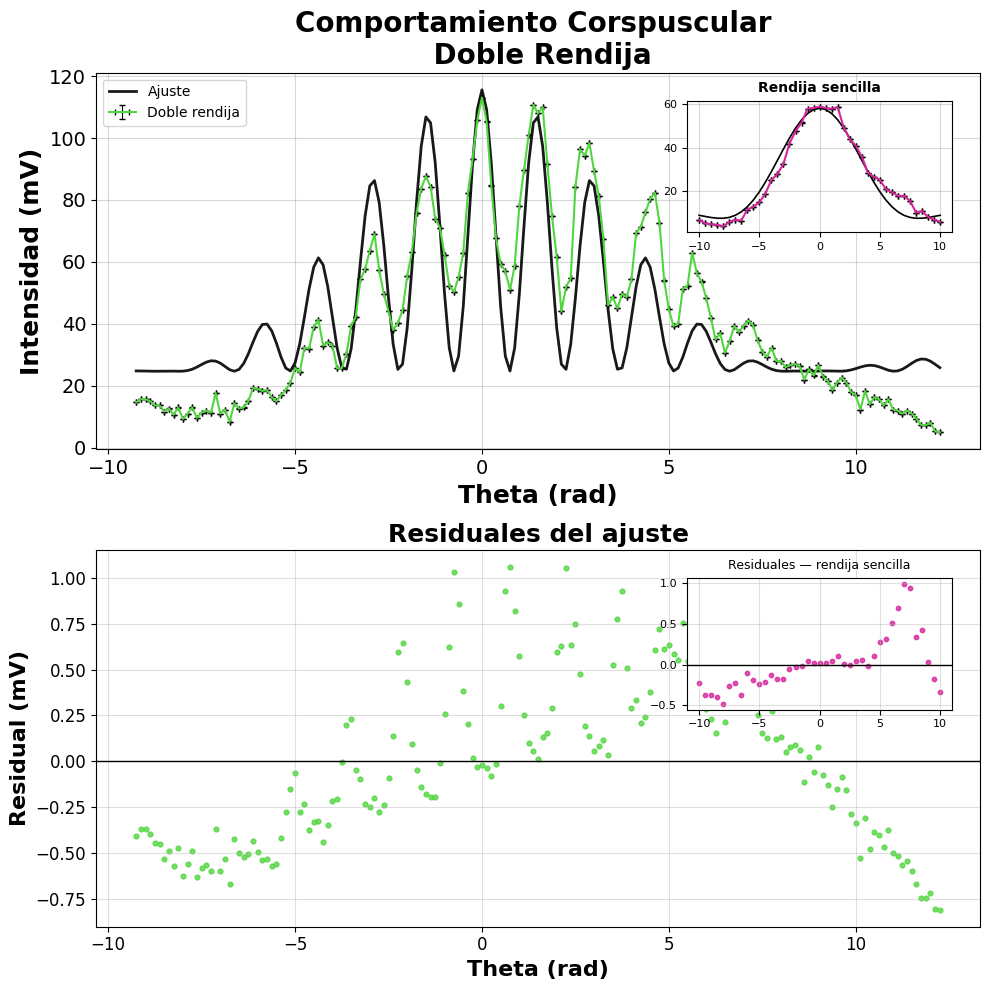

In [ ]:
# ================================================
#   1. CARGA DE DATOS
# ================================================
ondulatorio_doble  = leer_columnas("Corpuscular_Doble_Rendija.txt")
ondulatorio_simple = leer_columnas("Corpuscular_Rendija_Sencilla.txt")

x_doble,  y_doble  = ondulatorio_doble[0],  ondulatorio_doble[1]
x_simple, y_simple = ondulatorio_simple[0], ondulatorio_simple[1]


# ================================================
#   2. CONVERSIÓN A ÁNGULO (CENTRAR EN MÁXIMO)
# ================================================
L = 40.0   # cm

idx_max_doble  = np.argmax(y_doble)
idx_max_simple = np.argmax(y_simple)

x_center_doble  = x_doble[idx_max_doble]
x_center_simple = x_simple[idx_max_simple]

theta_doble  = (x_doble  - x_center_doble)  / L
theta_simple = (x_simple - x_center_simple) / L


# ================================================
#   3. INCERTIDUMBRES
# ================================================
dx_error = 0.0005   # cm
dy_error = 0.01     # mV

dtheta_doble  = dx_error / L
dtheta_simple = dx_error / L

# ---- Ajuste doble rendija ----
p0_doble = [
    np.max(y_doble) - np.min(y_doble),   # I0
    np.min(y_doble),                     # Ibg
    2.5,                                 # b
    0.1
]

popt_doble, _ = curve_fit(I_fraunhofer_flexible,
                          theta_doble, y_doble,
                          p0=p0_doble)

yfit_doble = I_fraunhofer_flexible(theta_doble, *popt_doble)


# ---- Ajuste rendija sencilla ----
p0_simple = [
    np.max(y_simple) - np.min(y_simple), # I0
    np.min(y_simple),                    # Ibg
    2.0,                                 # b
    0.3                                 # alpha
]

popt_simple, _ = curve_fit(I_rendija_simple,
                           theta_simple, y_simple,
                           p0=p0_simple)

yfit_simple = I_rendija_simple(theta_simple, *popt_simple)


plot_patron(
    theta_doble,  y_doble,  yfit_doble,
    theta_simple, y_simple, yfit_simple,
    "Comportamiento Corspuscular \n Doble Rendija",
    dx_error_principal=dtheta_doble,
    dx_error_segundario=dtheta_simple,
    dy_error=dy_error
)



In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- Función para leer columnas y convertir ',' a '.' ---
def leer_columnas(file_path, cols=(0,1), skip_header=1, delimiter='\t'):
    converters = {i: lambda s: float(s.replace(',', '.')) for i in cols}  # quitar decode()
    return np.genfromtxt(file_path, usecols=cols, unpack=True, skip_header=skip_header,
                         delimiter=delimiter, converters=converters, encoding='utf-8')


# --- Función de intensidad doble rendija ---
def I_theta(theta, I0, lambda_, Ibg):
    a = 0.1e-3      # ancho de rendija en m
    d = 0.356e-3    # separación de rendijas en m
    beta = np.pi * a / lambda_ * theta
    gamma = np.pi * d / lambda_ * theta
    beta = np.where(beta == 0, 1e-10, beta)  # evitar división por cero
    return I0 * (np.sin(beta)/beta)**2 * (np.cos(gamma))**2 + Ibg

# --- Parámetros experimentales ---
L_verde = 50*10e-3  # distancia pantalla-fuente (m)
L_rojo = 50*10e-3

# --- AJUSTE LUZ VERDE ---
ondulatorio_doble = leer_columnas("Corpuscular_Doble_Rendija.txt")
x_doble = ondulatorio_doble[0]
y_doble = ondulatorio_doble[1]

x_doble = x_doble * 1e-6  # convertir de nm a m
x_central_doble = x_doble[np.argmax(y_doble)]
theta_doble = (x_doble - x_central_doble) / L_verde

popt_doble, pcov_doble = curve_fit(I_theta, theta_doble, y_doble, p0=[max(y_doble), 500e-9, min(y_doble)])
I0_d, lambda_d, Ibg_d = popt_doble
err_d = np.sqrt(np.diag(pcov_doble))
print(f"Luz verde: λ = {lambda_d*1e9:.2f} nm ± {err_d[1]*1e9:.2f} nm")

# --- AJUSTE LASER ROJO ---
ondulatorio_rojo = leer_columnas("Ondulatorio_Doble_Rendija.txt")
x_rojo = ondulatorio_rojo[0]
y_rojo = ondulatorio_rojo[1]

x_rojo = x_rojo * 1e-6
x_central_rojo = x_rojo[np.argmax(y_rojo)]
theta_rojo = (x_rojo - x_central_rojo) / L_rojo

popt_rojo, pcov_rojo = curve_fit(I_theta, theta_rojo, y_rojo, p0=[max(y_rojo), 650e-9, min(y_rojo)])
I0_r, lambda_r, Ibg_r = popt_rojo
err_r = np.sqrt(np.diag(pcov_rojo))
print(f"Láser rojo: λ = {lambda_r*1e9:.2f} nm ± {err_r[1]*1e9:.2f} nm")



FileNotFoundError: Corpuscular_Doble_Rendija.txt not found.